<a href="https://colab.research.google.com/github/CoderCouple/hands-on-pytorch/blob/main/ch_03_pytorch_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Computer Vision

In [2]:
#import the basic libraries
import torch
from torch import nn

import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt
from PIL import Image
from time import time

In [3]:
#check the versions
print(torch.__version__)
print(torchvision.__version__)

2.11.0+cu130
0.26.0+cu130


In [4]:
train_data = torchvision.datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

test_data = torchvision.datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

100%|██████████| 26.4M/26.4M [00:00<00:00, 113MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 7.23MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 60.4MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 31.0MB/s]


In [5]:
len(train_data), len(test_data)

(60000, 10000)

In [6]:
train_data[0]

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [7]:
train_data.classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [8]:
train_data.targets

tensor([9, 0, 0,  ..., 3, 0, 5])

In [9]:
image, lable = train_data[0]
image, lable

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [10]:
image.shape, lable

(torch.Size([1, 28, 28]), 9)

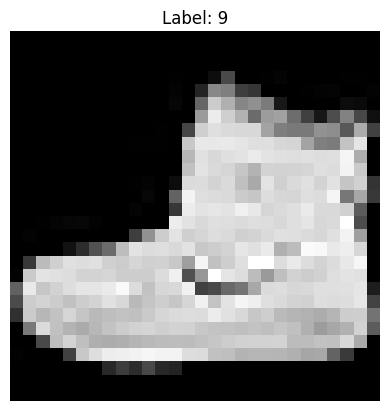

In [11]:
def display_image(image, lable):
  plt.figure()
  plt.imshow(image.squeeze(), cmap="gray")
  plt.title(f"Label: {lable}")
  plt.axis(False)

display_image(image=image, lable=lable)

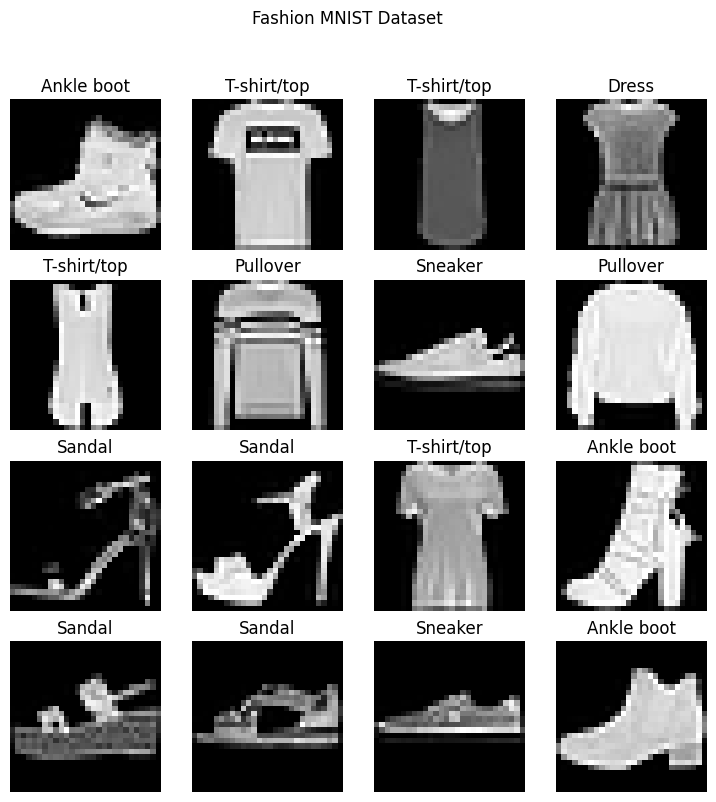

In [12]:
def display_image_grid(train_data):
  torch.manual_seed(28)
  fig = plt.figure(figsize=(9, 9))
  fig.suptitle("Fashion MNIST Dataset")
  for i in range(16):
    random_index = torch.randint(0, len(train_data), size=[1]).item()
    image, lable = train_data[i]
    fig.add_subplot(4, 4, i+1)
    plt.imshow(image.squeeze(), cmap="gray")

    plt.title(f"{train_data.classes[lable]}")
    plt.axis(False)

display_image_grid(train_data=train_data)

In [13]:
from torch.utils.data import DataLoader
#Dataloader
train_dataloader = DataLoader(
  dataset=train_data,
  batch_size=32,
  shuffle=True
)

test_dataloader= DataLoader(
    dataset=test_data,
    batch_size=32,
    shuffle=False
)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x786a78d05be0>,
 <torch.utils.data.dataloader.DataLoader at 0x786a71f37390>)

# LESTS BUILD THE MODEL V0

In [14]:
class FassionMNINSTModelV0(nn.Module):
  def __init__(self, input_shape, hiddend_shape, output_shape):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape, out_features=hiddend_shape),
        nn.Linear(in_features=hiddend_shape, out_features=output_shape)
    )

  def forward(self, x:torch.Tensor) -> torch.Tensor:
    return self.layer_stack(x)

model_0 = FassionMNINSTModelV0(input_shape=784, hiddend_shape=10, output_shape=10).to("cpu")
model_0

FassionMNINSTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [15]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  # Note: you need the "raw" GitHub URL for this to work
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

In [16]:
# Create the loss functiuon and optimizers
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01)

In [17]:
# How to time your model
from timeit import default_timer as timer
def print_train_time(start: float, end: float, device:torch.device = None ):
  """
  print the difference between start time and end time
  """
  total_time= end - start
  print(f"train time on device {device} is :{total_time:.3f} seconds")






In [18]:
start = timer()

# some code

end = timer()
print_train_time(start=start, end=end, device="cpu")

train time on device cpu is :0.003 seconds


In [19]:
#creating the training and test loop
from tqdm.auto import tqdm

epochs = 3
torch.manual_seed(28)
torch.cuda.manual_seed(28)

train_start_time = timer()
#building the training loop
for epoch in tqdm(range(epochs)):
  print(f"Epoch : {epoch}")
  train_loss = 0
  train_acc = 0

  # Put model in training mode
  model_0.train()

  for batch, (X, Y) in enumerate(train_dataloader):
    #1. forward pass
    y_preds = model_0(X)

    #2. calculate the loss for the current batch
    loss = loss_fn(y_preds, Y)
    train_loss += loss.item() # accumulate the loss value as a float to prevent graph building

    # Fix: Get the prediction labels (argmax) and use correct keyword arguments
    train_acc += accuracy_fn(y_true=Y, y_pred=y_preds.argmax(dim=1))

    #3. Zero gradient
    optimizer.zero_grad()

    #4. Backward pass
    loss.backward()

    #5. Optimizer step
    optimizer.step()

    #Seen sample
    if batch % 400 == 0:
      print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples")

  # Fix: Move these outside the training batch loop so they execute once per epoch
  train_loss /= len(train_dataloader)
  train_acc /= len(train_dataloader)

  ##Testing the model
  test_loss = 0
  test_acc = 0

  model_0.eval()
  with torch.inference_mode():
    for X, Y in test_dataloader:
      test_preds = model_0(X)
      test_loss += loss_fn(test_preds, Y).item()
      test_acc += accuracy_fn(y_true=Y, y_pred=test_preds.argmax(dim=1))

    test_loss /= len(test_dataloader)
    test_acc /= len(test_dataloader)

  print(f"Train loss: {train_loss:.5f} | Train acc: {train_acc:.2f}% | Test loss: {test_loss:.5f} | Test acc: {test_acc:.2f}%")

train_end_time = timer()
print_train_time(start=train_start_time, end=train_end_time, device="cpu")

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch : 0
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train loss: 0.87470 | Train acc: 70.34% | Test loss: 0.63961 | Test acc: 77.89%
Epoch : 1
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train loss: 0.56469 | Train acc: 80.93% | Test loss: 0.55609 | Test acc: 80.57%
Epoch : 2
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train loss: 0.50677 | Train acc: 82.64% | Test loss: 0.51862 | Test acc: 81.76%
train time on device cpu is :34.400 seconds


In [20]:
#write a generic model evaluation function

torch.manual_seed(42)
def eval_model(
    model:torch.nn.Module,
    dataloader:torch.utils.data.DataLoader,
    loss_fn:torch.nn.Module,
    accuracy_fn:callable,
    device:torch.device = "cpu"
):
  test_loss, test_acc = 0, 0
  model.eval()
  with torch.inference_mode():
    for X, Y in dataloader:

      # make the prediction
      X, Y = X.to(device), Y.to(device)
      test_preds = model(X)

      #accumulate the loss
      test_loss += loss_fn(test_preds, Y).item()
      # Fix: convert raw logits to prediction labels using argmax(dim=1)
      test_acc += accuracy_fn(y_true=Y, y_pred=test_preds.argmax(dim=1))

  # scale the loss and accuracy
  test_loss = test_loss / len(dataloader)
  test_acc = test_acc / len(dataloader)

  # Fix: return the correct accumulated metrics (test_loss and test_acc)
  return {"model_name":model.__class__.__name__,
          "model_loss":test_loss,
          "model_acc":test_acc}

In [21]:
model_0_results = eval_model(
    model=model_0,
    dataloader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn,
    device="cpu"
)

model_0_results

{'model_name': 'FassionMNINSTModelV0',
 'model_loss': 0.5186170330538917,
 'model_acc': 81.75918530351437}

In [22]:
!nvidia-smi

Tue Oct  6 21:34:56 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [23]:
# making the code device agnostic
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [43]:
class FassionMNINSTModelV1(nn.Module):
  def __init__(self, input_shape, hiddend_shape, output_shape):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape,out_features=hiddend_shape),
        nn.ReLU(),
        nn.Linear(in_features=hiddend_shape, out_features=output_shape),
        nn.ReLU()
    )

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.layer_stack(x)

model_1 = FassionMNINSTModelV1(input_shape=784, hiddend_shape=10, output_shape=10).to(device)
model_1



FassionMNINSTModelV1(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): ReLU()
    (3): Linear(in_features=10, out_features=10, bias=True)
    (4): ReLU()
  )
)

In [44]:
from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.01)

In [45]:
#functinalize the code

def train_step(
    model: torch.nn.Module,
    dataloader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    accuracy_fn: callable,
    device: torch.device = "cpu"
):
  """ Perform traing on a model """

  # out model in training mode
  model.train()
  train_loss, train_acc = 0, 0

  # enumarate over the data
  for batch, (X,Y) in enumerate(dataloader):

    #put the date on the target device
    X, Y = X.to(device), Y.to(device)

    #1. Forward pass
    y_train_preds = model(X)

    #2. Calculate the loss
    loss = loss_fn(y_train_preds, Y)
    train_loss += loss.item()
    train_acc += accuracy_fn(y_true=Y, y_pred=y_train_preds.argmax(dim=1))

    #3. Zero gradient
    optimizer.zero_grad()

    #4. Backward pas
    loss.backward()

    #5. Optimizer step
    optimizer.step()

    # Logging
    if batch % 400 == 0:
      print(f"Looked at {batch * len(X)}/{len(dataloader.dataset)} samples")

# scalling the loss and accuracy
  train_loss /= len(dataloader)
  train_acc /= len(dataloader)
  print(f"Train loss: {train_loss:.5f} | Train acc: {train_acc:.2f}%")





In [49]:
# functionizing the test step
def test_step(
    model: torch.nn.Module,
    dataloader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    accuracy_fn: callable,
    device: torch.device = "cpu"
):

# put the model in eval mode
  model.eval()
  test_loss, test_acc = 0, 0

# enumerate for the test data
  with torch.inference_mode():
    for X, Y in dataloader:

      #move the data to target device
      X, Y = X.to(device), Y.to(device)

      #1. Forward pass
      test_preds = model(X)

      #2. Calculate the loss (accumulating as a float using .item())
      test_loss += loss_fn(test_preds, Y).item()
      test_acc += accuracy_fn(y_true=Y, y_pred=test_preds.argmax(dim=1))

      # scalling the loss and accuracy
  test_loss /= len(dataloader)
  test_acc /= len(dataloader)
  print(f"Test loss: {test_loss:.5f} | Test acc: {test_acc:.2f}%")

In [47]:
# Inspect the model and dataloader
print(model_1)
print(train_dataloader)

FassionMNINSTModelV1(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): ReLU()
    (3): Linear(in_features=10, out_features=10, bias=True)
    (4): ReLU()
  )
)


In [50]:
# training loop

torch.manual_seed(42)
torch.cuda.manual_seed(42)

#measure time
epochs = 3
train_start_time_on_gpu = timer()

for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n---------")
  train_step(
      model=model_1,
      dataloader=train_dataloader,
      loss_fn=loss_fn,
      optimizer=optimizer,
      accuracy_fn=accuracy_fn,
      device=device
  )
  test_step(
      model=model_1,
      dataloader=test_dataloader,
      loss_fn=loss_fn,
      accuracy_fn=accuracy_fn,
      device=device
  )
  print()

train_end_time_on_gpu = timer()
print_train_time(start=train_start_time_on_gpu, end=train_end_time_on_gpu, device=device)



  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
---------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train loss: 0.88922 | Train acc: 69.27%
Test loss: 0.83497 | Test acc: 70.29%

Epoch: 1
---------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train loss: 0.72540 | Train acc: 74.86%
Test loss: 0.60943 | Test acc: 79.87%

Epoch: 2
---------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train loss: 0.54843 | Train acc: 81.52%
Test loss: 0.54459 | Test acc: 81.32%

train time on device cuda is :29.926 seconds


# Lets start building out first Convolutional Neural Network


In [53]:
class FassionMNINSTModelV2(nn.Module):
  pass